# CFTC/COT WTI Data Processing

This notebook prepares Commitment of Traders (COT) data from the CFTC for use in the WTI crude oil direction-forecasting pipeline. The goal is to build futures-positioning features that capture trader behavior, speculative pressure, and market participation without introducing look-ahead bias.

The workflow is:

1. Download and combine historical CFTC disaggregated futures reports.
2. Filter the reports to the WTI crude oil futures contract.
3. Clean dates and numeric fields.
4. Engineer COT positioning features.
5. Resample weekly COT data to daily frequency and apply the reporting-delay adjustment.
6. Merge the COT features into the main WTI/macroeconomic modeling dataset.
7. Export the final modeling dataset.

## 1. Imports and CFTC Download Function

The CFTC publishes historical disaggregated futures reports as yearly zip files. The helper function below downloads one year of data, reads the text file inside the zip archive, and returns it as a DataFrame.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import requests

from zipfile import ZipFile
from io import BytesIO


def load_disagg_cot_year(year):
    """Download one year of CFTC disaggregated futures data."""
    url = f"https://www.cftc.gov/files/dea/history/fut_disagg_txt_{year}.zip"

    response = requests.get(url)
    response.raise_for_status()

    with ZipFile(BytesIO(response.content)) as z:
        file_name = z.namelist()[0]
        df = pd.read_csv(z.open(file_name))

    df["year"] = year
    return df


def comma_formatter(x, pos):
    """Format chart axis values as comma-separated whole numbers."""
    return f"{int(x):,}"

## 2. Load Historical CFTC Data

I load CFTC disaggregated reports from 2010 through 2025. The final merged modeling dataset begins later because it also depends on the availability of the WTI/macroeconomic dataset and the reporting-delay adjustment.

In [2]:
years = range(2010, 2026)

dfs = []

for year in years:
    print(f"Loading {year}...")
    df_year = load_disagg_cot_year(year)
    dfs.append(df_year)

cot_disagg = pd.concat(dfs, ignore_index=True)

print(cot_disagg.shape)
print(cot_disagg.columns.tolist())

Loading 2010...


C:\Users\Nancy Lonoff\AppData\Local\Temp\ipykernel_51424\679998085.py:19: DtypeWarning: Columns (133,145,146,147,148,149,159,160) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(file_name))


Loading 2011...


C:\Users\Nancy Lonoff\AppData\Local\Temp\ipykernel_51424\679998085.py:19: DtypeWarning: Columns (133,147,148,149,150,159,160) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(file_name))


Loading 2012...


...

Loading 2024...


C:\Users\Nancy Lonoff\AppData\Local\Temp\ipykernel_51424\679998085.py:19: DtypeWarning: Columns (120,132,133,134,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(file_name))


Loading 2025...


C:\Users\Nancy Lonoff\AppData\Local\Temp\ipykernel_51424\679998085.py:19: DtypeWarning: Columns (120,132,134,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(file_name))


(160607, 193)
['Market_and_Exchange_Names', 'As_of_Date_In_Form_YYMMDD', 'Report_Date_as_MM_DD_YYYY', 'CFTC_Contract_Market_Code', 'CFTC_Market_Code', 'CFTC_Region_Code', 'CFTC_Commodity_Code', 'Open_Interest_All', 'Prod_Merc_Positions_Long_All', 'Prod_Merc_Positions_Short_All', 'Swap_Positions_Long_All', 'Swap__Positions_Short_All', 'Swap__Positions_Spread_All', 'M_Money_Positions_Long_All', 'M_Money_Positions_Short_All', 'M_Money_Positions_Spread_All', 'Other_Rept_Positions_Long_All', 'Other_Rept_Positions_Short_All', 'Other_Rept_Positions_Spread_All', 'Tot_Rept_Positions_Long_All', 'Tot_Rept_Positions_Short_All', 'NonRept_Positions_Long_All', 'NonRept_Positions_Short_All', 'Open_Interest_Old', 'Prod_Merc_Positions_Long_Old', 'Prod_Merc_Positions_Short_Old', 'Swap_Positions_Long_Old', 'Swap__Positions_Short_Old', 'Swap__Positions_Spread_Old', 'M_Money_Positions_Long_Old', 'M_Money_Positions_Short_Old', 'M_Money_Positions_Spread_Old', 'Other_Rept_Positions_Long_Old', 'Other_Rept_Posit

## 3. Filter to WTI Crude Oil Futures

The full CFTC file contains many futures markets. I filter to the WTI crude oil futures contract using the CFTC contract market code `067651`, which corresponds to NYMEX WTI crude oil.

In [3]:
wti = cot_disagg[
    cot_disagg["CFTC_Contract_Market_Code"].astype(str).str.zfill(6) == "067651"
].copy()

print(wti.shape)
wti[["Market_and_Exchange_Names", "CFTC_Contract_Market_Code"]].drop_duplicates()

(574, 193)


,Market_and_Exchange_Names,CFTC_Contract_Market_Code
43992,"CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE E...",067651
119675,WTI-PHYSICAL - NEW YORK MERCANTILE EXCHANGE,067651


## 4. Clean Dates and Numeric Fields

The COT reports are weekly. I convert the report date to a datetime index, sort chronologically, and convert the fields needed for feature engineering into numeric values. This step makes the later feature calculations and plots consistent.

In [4]:
wti["date"] = pd.to_datetime(wti["Report_Date_as_YYYY-MM-DD"])
wti = wti.sort_values("date").set_index("date")

numeric_columns = [
    "Change_in_M_Money_Long_All",
    "Change_in_M_Money_Short_All",
    "M_Money_Positions_Long_All",
    "M_Money_Positions_Short_All",
    "Open_Interest_All",
    "Pct_of_OI_M_Money_Long_All",
    "Pct_of_OI_M_Money_Short_All",
]

for col in numeric_columns:
    wti[col] = (
        wti[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

wti.head()

,Market_and_Exchange_Names,As_of_Date_In_Form_YYMMDD,Report_Date_as_MM_DD_YYYY,CFTC_Contract_Market_Code,CFTC_Market_Code,CFTC_Region_Code,CFTC_Commodity_Code,Open_Interest_All,Prod_Merc_Positions_Long_All,Prod_Merc_Positions_Short_All,...,Conc_Net_LE_8_TDR_Long_Other,Conc_Net_LE_8_TDR_Short_Other,Contract_Units,CFTC_Contract_Market_Code_Quotes,CFTC_Market_Code_Quotes,CFTC_Commodity_Code_Quotes,CFTC_SubGroup_Code,FutOnly_or_Combined,year,Report_Date_as_YYYY-MM-DD
date,,,,,,,,,,,,,,,,,,,,,
2015-01-06,"CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE E...",150106,NaN,067651,NYME,1,67,1505101.0,205377,286774,...,0.0,0.0,"(CONTRACTS OF 1,000 BARRELS)",067651,NYME,67,N10,FutOnly,2015,2015-01-06
2015-01-13,"CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE E...",150113,NaN,067651,NYME,1,67,1627535.0,229511,330911,...,0.0,0.0,"(CONTRACTS OF 1,000 BARRELS)",067651,NYME,67,N10,FutOnly,2015,2015-01-13
2015-01-20,"CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE E...",150120,NaN,067651,NYME,1,67,1591022.0,223956,339795,...,0.0,0.0,"(CONTRACTS OF 1,000 BARRELS)",067651,NYME,67,N10,FutOnly,2015,2015-01-20
2015-01-27,"CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE E...",150127,NaN,067651,NYME,1,67,1668047.0,255666,380108,...,0.0,0.0,"(CONTRACTS OF 1,000 BARRELS)",067651,NYME,67,N10,FutOnly,2015,2015-01-27
2015-02-03,"CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE E...",150203,NaN,067651,NYME,1,67,1721471.0,258305,382736,...,0.0,0.0,"(CONTRACTS OF 1,000 BARRELS)",067651,NYME,67,N10,FutOnly,2015,2015-02-03


## 5. Inspect Available Columns

This cell creates a simple column dictionary so I can confirm which COT fields are available before selecting the variables used in the final feature set.

In [5]:
columns_df = pd.DataFrame({
    "column_number": range(len(wti.columns)),
    "column_name": wti.columns,
})

pd.set_option("display.max_rows", 20)
columns_df

,column_number,column_name
0,0,Market_and_Exchange_Names
1,1,As_of_Date_In_Form_YYMMDD
2,2,Report_Date_as_MM_DD_YYYY
3,3,CFTC_Contract_Market_Code
4,4,CFTC_Market_Code
...,...,...
188,188,CFTC_Commodity_Code_Quotes
189,189,CFTC_SubGroup_Code
190,190,FutOnly_or_Combined
191,191,year


## 6. Engineer COT Positioning Features

The raw COT variables are transformed into a smaller set of interpretable positioning features:

- **Net positioning:** managed-money long positions minus managed-money short positions.
- **Net positioning percent:** managed-money long share of open interest minus managed-money short share.
- **Flow:** weekly change in managed-money longs minus weekly change in managed-money shorts.
- **Long-short ratio:** managed-money longs divided by managed-money shorts.
- **Open interest change:** week-to-week change in total market participation.

These variables summarize the direction and intensity of speculative positioning rather than using only raw contract counts.

In [6]:
wti["net_position"] = (
    wti["M_Money_Positions_Long_All"]
    - wti["M_Money_Positions_Short_All"]
)

wti["net_position_pct"] = (
    wti["Pct_of_OI_M_Money_Long_All"]
    - wti["Pct_of_OI_M_Money_Short_All"]
)

wti["flow"] = (
    wti["Change_in_M_Money_Long_All"]
    - wti["Change_in_M_Money_Short_All"]
)

wti["long_short_ratio"] = (
    wti["M_Money_Positions_Long_All"]
    / wti["M_Money_Positions_Short_All"]
)

wti["oi_change"] = wti["Open_Interest_All"].diff()

feature_cols = [
    "net_position",
    "net_position_pct",
    "flow",
    "long_short_ratio",
    "Open_Interest_All",
    "oi_change",
]

wti[feature_cols].describe()

,net_position,net_position_pct,flow,long_short_ratio,Open_Interest_All,oi_change
count,574.000000,574.000000,574.000000,574.000000,5.740000e+02,573.000000
mean,209118.761324,10.381359,-311.395470,5.141601,1.973315e+06,686.136126
std,104531.586283,4.373602,27871.846448,4.200299,2.817129e+05,50438.523074
min,-38154.000000,-1.900000,-113736.000000,0.770473,1.395622e+06,-201412.000000
25%,136069.500000,7.200000,-16564.250000,2.356140,1.748129e+06,-32098.000000
50%,195846.000000,10.700000,-1138.000000,4.021467,1.967563e+06,2805.000000
75%,279650.500000,13.600000,16506.500000,6.464013,2.151732e+06,32670.000000
max,483829.000000,19.200000,89828.000000,29.615037,2.706454e+06,199388.000000


## 7. Exploratory Plots

The following plots are used for exploratory analysis. They show how speculative positioning, normalized positioning, positioning flows, long-short ratios, and open interest evolved over time.

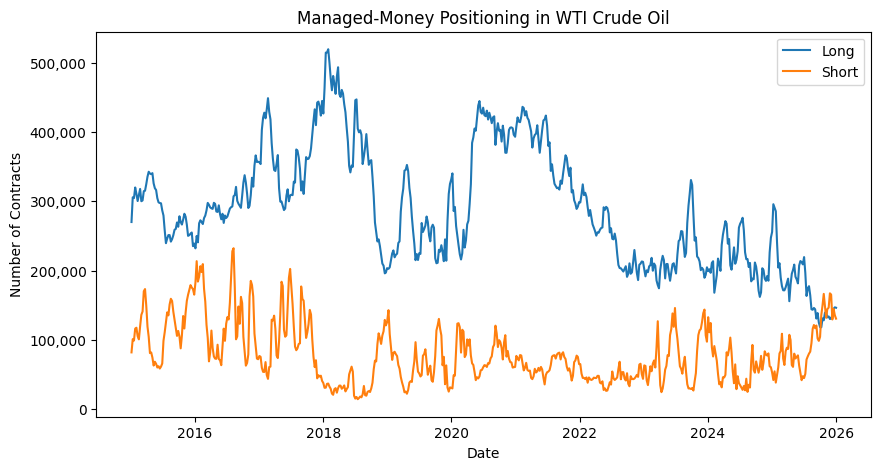

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(wti.index, wti["M_Money_Positions_Long_All"], label="Long")
ax.plot(wti.index, wti["M_Money_Positions_Short_All"], label="Short")

ax.set_title("Managed-Money Positioning in WTI Crude Oil")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Contracts")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(comma_formatter))
ax.legend()

plt.show()

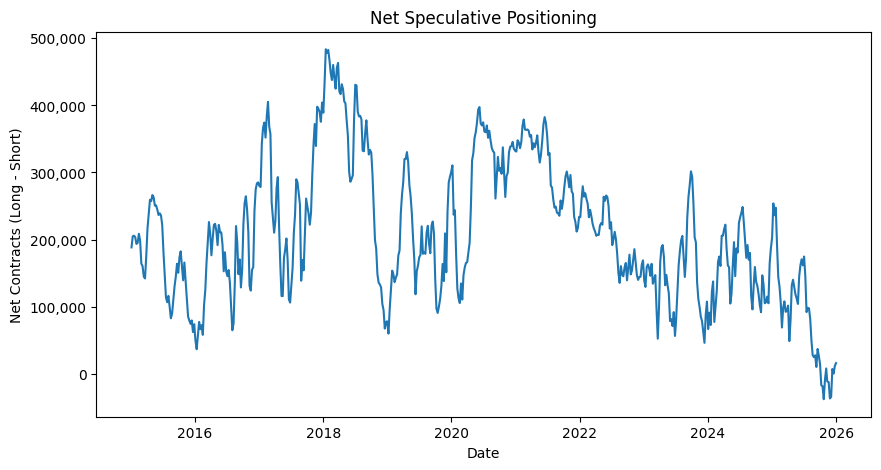

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(wti.index, wti["net_position"])

ax.set_title("Net Speculative Positioning")
ax.set_xlabel("Date")
ax.set_ylabel("Net Contracts (Long - Short)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(comma_formatter))

plt.show()

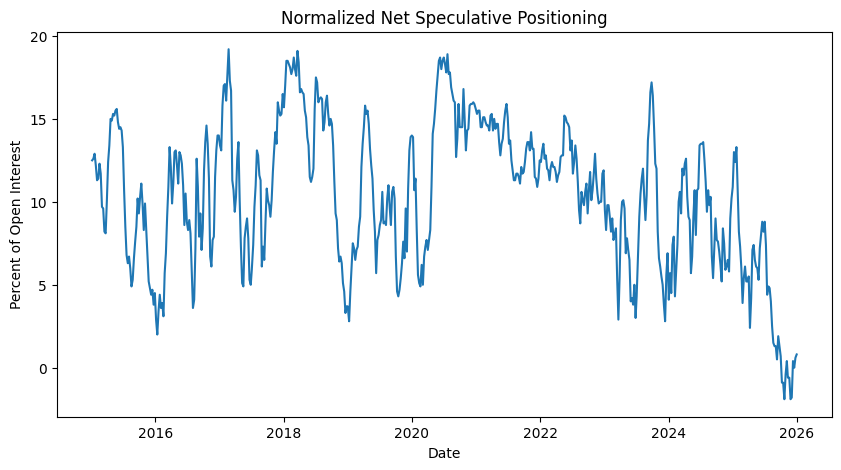

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(wti.index, wti["net_position_pct"])

ax.set_title("Normalized Net Speculative Positioning")
ax.set_xlabel("Date")
ax.set_ylabel("Percent of Open Interest")

plt.show()

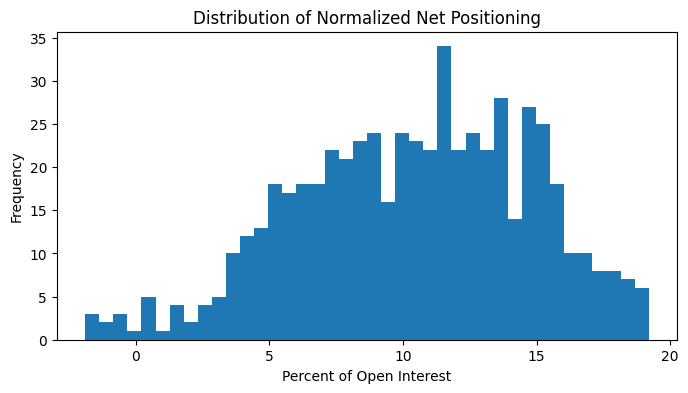

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(wti["net_position_pct"].dropna(), bins=40)

ax.set_title("Distribution of Normalized Net Positioning")
ax.set_xlabel("Percent of Open Interest")
ax.set_ylabel("Frequency")

plt.show()

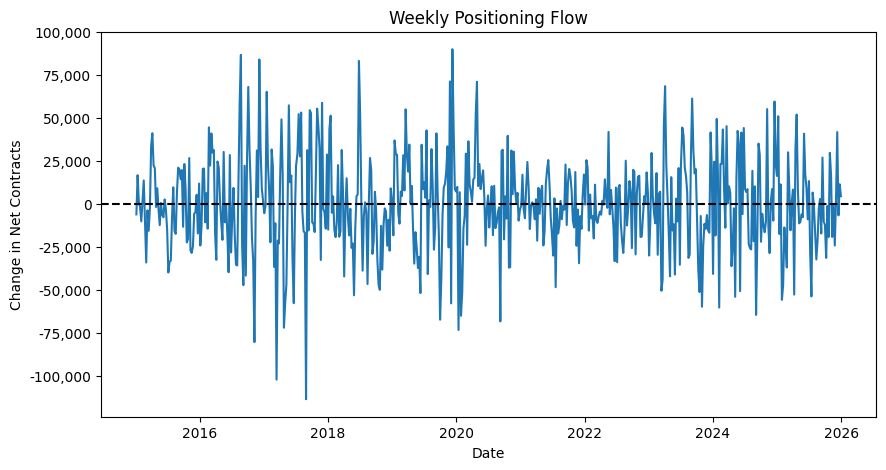

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(wti.index, wti["flow"])

ax.set_title("Weekly Positioning Flow")
ax.set_xlabel("Date")
ax.set_ylabel("Change in Net Contracts")
ax.axhline(0, linestyle="--", color="black")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(comma_formatter))

plt.show()

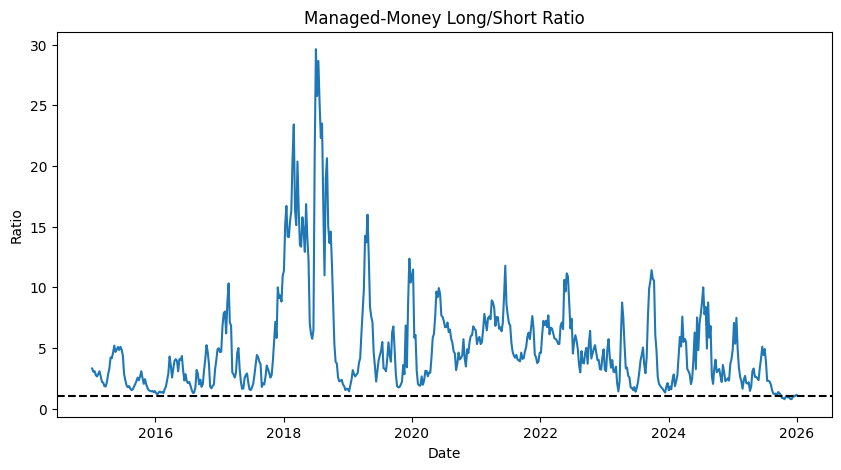

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(wti.index, wti["long_short_ratio"])

ax.set_title("Managed-Money Long/Short Ratio")
ax.set_xlabel("Date")
ax.set_ylabel("Ratio")
ax.axhline(1, linestyle="--", color="black")

plt.show()

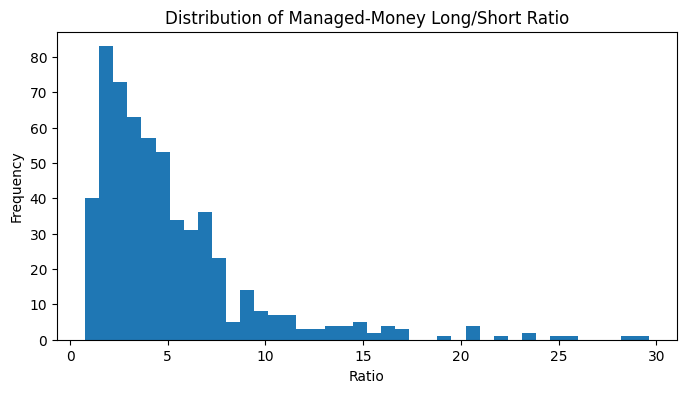

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(wti["long_short_ratio"].dropna(), bins=40)

ax.set_title("Distribution of Managed-Money Long/Short Ratio")
ax.set_xlabel("Ratio")
ax.set_ylabel("Frequency")

plt.show()

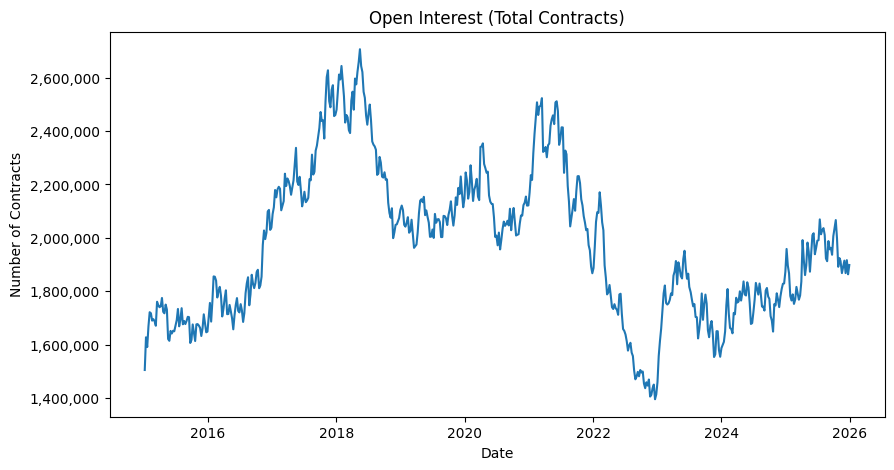

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(wti.index, wti["Open_Interest_All"])

ax.set_title("Open Interest (Total Contracts)")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Contracts")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(comma_formatter))

plt.show()

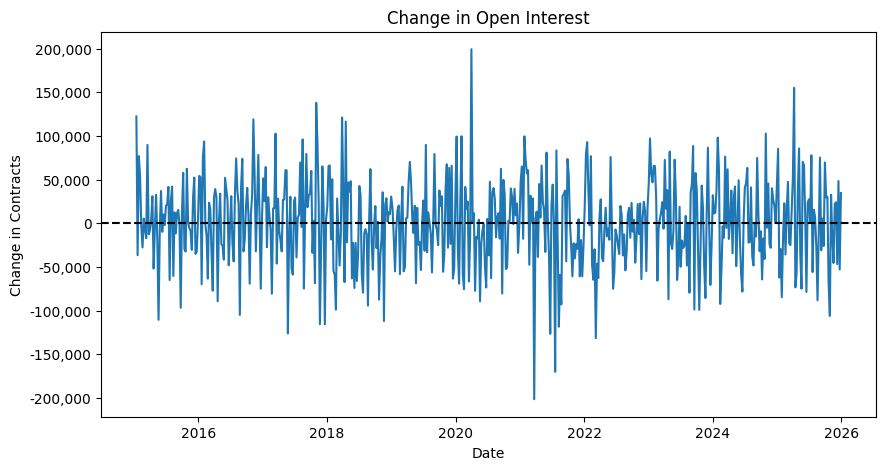

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(wti.index, wti["oi_change"])

ax.set_title("Change in Open Interest")
ax.set_xlabel("Date")
ax.set_ylabel("Change in Contracts")
ax.axhline(0, linestyle="--", color="black")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(comma_formatter))

plt.show()

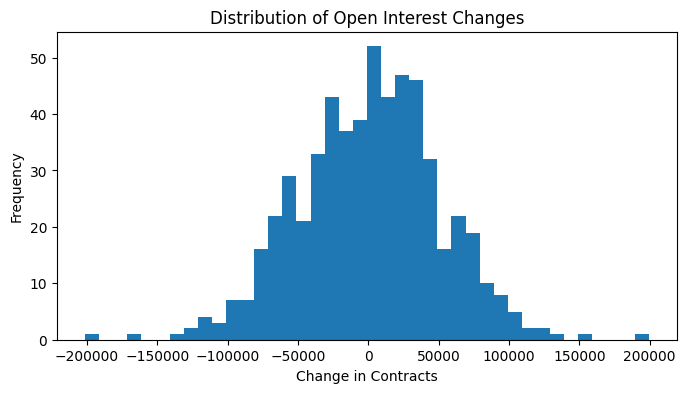

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(wti["oi_change"].dropna(), bins=40)

ax.set_title("Distribution of Open Interest Changes")
ax.set_xlabel("Change in Contracts")
ax.set_ylabel("Frequency")

plt.show()

## 8. Save Weekly COT Feature File

This file contains the cleaned weekly WTI COT data with engineered features. It is useful as an intermediate output because it separates the alternative-data construction step from the final model-ready daily dataset.

In [17]:
wti.to_csv("CFTC_WTI_data.csv", header=True)

## 9. Load Main WTI/Macroeconomic Dataset

The main dataset should be saved in the same folder as this notebook as `original_data.csv`. I avoid using a local absolute path so the notebook can be run on another machine without changing a personal file path.

In [19]:
MAIN_DATA_PATH = "original_data.csv"

df = pd.read_csv(MAIN_DATA_PATH)

df_main = df.copy()
df_main["Date"] = pd.to_datetime(df_main["Date"])
df_main = df_main.set_index("Date").sort_index()

df_main.head()

,Price,macro_month,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,...,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPICMM,UMCSENTx,Target
Date,,,,,,,,,,,,,,,,,,,,,
1999-09-01,21.99,1999-08-01,11111.719,9681.7,1043658.0,98.7651,5864.7,15000.1,969.3807,112.225134,...,0.87,2.33,3.08,1.5093,113.2268,1.6058,1.4932,107.9,104.5,0
1999-09-02,21.49,1999-08-01,11111.719,9681.7,1043658.0,98.7651,5864.7,15000.1,969.3807,112.225134,...,0.87,2.33,3.08,1.5093,113.2268,1.6058,1.4932,107.9,104.5,1
1999-09-03,22.00,1999-08-01,11111.719,9681.7,1043658.0,98.7651,5864.7,15000.1,969.3807,112.225134,...,0.87,2.33,3.08,1.5093,113.2268,1.6058,1.4932,107.9,104.5,1
1999-09-07,22.61,1999-08-01,11111.719,9681.7,1043658.0,98.7651,5864.7,15000.1,969.3807,112.225134,...,0.87,2.33,3.08,1.5093,113.2268,1.6058,1.4932,107.9,104.5,1
1999-09-08,22.66,1999-08-01,11111.719,9681.7,1043658.0,98.7651,5864.7,15000.1,969.3807,112.225134,...,0.87,2.33,3.08,1.5093,113.2268,1.6058,1.4932,107.9,104.5,1


## 10. Convert Weekly COT Features to Daily Features

WTI prices are observed daily, while COT data is weekly. I resample the selected COT features to daily frequency and forward-fill each weekly observation until a new report becomes available.

COT reports measure trader positions as of Tuesday but are usually released on Friday. To avoid look-ahead bias, I delay the forward-filled COT features by three calendar days. This prevents the model from using Tuesday positioning information before it would have been publicly available.

In [20]:
cot = wti[feature_cols].copy()

# Forward-fill weekly COT values to daily frequency.
cot_daily = cot.resample("D").ffill()

# Delay the information by three calendar days to reflect the Tuesday-to-Friday reporting lag.
cot_daily = cot_daily.shift(3)

cot_daily.head(10)

,net_position,net_position_pct,flow,long_short_ratio,Open_Interest_All,oi_change
date,,,,,,
2015-01-06,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-08,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-09,188251.0,12.5,-6233.0,3.302511,1505101.0,NaN
2015-01-10,188251.0,12.5,-6233.0,3.302511,1505101.0,NaN
2015-01-11,188251.0,12.5,-6233.0,3.302511,1505101.0,NaN
2015-01-12,188251.0,12.5,-6233.0,3.302511,1505101.0,NaN
2015-01-13,188251.0,12.5,-6233.0,3.302511,1505101.0,NaN
2015-01-14,188251.0,12.5,-6233.0,3.302511,1505101.0,NaN


## 11. Merge COT Features into the Forecasting Dataset

The daily COT features are joined to the main WTI/macroeconomic dataset by date. The merged data is restricted to the period where COT information is available, and rows with missing values are removed after all rolling features are created.

In [21]:
df_merged = df_main.join(cot_daily, how="left")

# Keep only the time period covered by the COT dataset.
df_merged = df_merged.loc[cot.index.min():cot.index.max()]

df_merged.isnull().sum()

Price                0
macro_month          0
RPI                  0
W875RX1              0
CMRMTSPLx            0
                    ..
net_position_pct     3
flow                 3
long_short_ratio     3
Open_Interest_All    3
oi_change            8
Length: 40, dtype: int64

## 12. Add Price-Based Summary Features

Instead of using a full 30-day raw price-lag window, I summarize recent price behavior with return-based and rolling features. These variables preserve recent price-history information while keeping the final feature set more compact and interpretable.

In [22]:
df_merged["returns"] = df_merged["Price"].pct_change()

# Short-horizon volatility and momentum.
df_merged["vol_20"] = df_merged["returns"].rolling(20).std()
df_merged["momentum_20"] = df_merged["Price"].pct_change(20)

# Longer-horizon volatility, drawdown, and trend features.
df_merged["vol_60"] = df_merged["returns"].rolling(60).std()
df_merged["drawdown"] = df_merged["Price"] / df_merged["Price"].rolling(60).max() - 1

df_merged["trend"] = (
    df_merged["Price"].rolling(20).mean()
    - df_merged["Price"].rolling(100).mean()
)

final_df = df_merged.dropna()

print(final_df.index.min())
print(final_df.index.max())
print(final_df.shape)

final_df.head()

2015-05-21 00:00:00
2025-10-31 00:00:00
(2749, 46)


,Price,macro_month,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,...,flow,long_short_ratio,Open_Interest_All,oi_change,returns,vol_20,momentum_20,vol_60,drawdown,trend
Date,,,,,,,,,,,,,,,,,,,,,
2015-05-21,60.72,2015-04-01,15833.624,13080.5,1321167.0,100.8979,5778.7,15522.1,1847.9368,161.578916,...,-3278.0,5.192346,1731678.0,-18404.0,0.029502,0.018927,0.051611,0.026722,-0.003447,7.6288
2015-05-22,59.72,2015-04-01,15833.624,13080.5,1321167.0,100.8979,5778.7,15522.1,1847.9368,161.578916,...,-12459.0,4.670001,1621198.0,-110480.0,-0.016469,0.019201,0.044969,0.026582,-0.019859,7.6394
2015-05-24,59.92,2015-04-01,15833.624,13080.5,1321167.0,100.8979,5778.7,15522.1,1847.9368,161.578916,...,-12459.0,4.670001,1621198.0,-110480.0,0.003349,0.019163,0.051413,0.026567,-0.016576,7.6732
2015-05-25,59.85,2015-04-01,15833.624,13080.5,1321167.0,100.8979,5778.7,15522.1,1847.9368,161.578916,...,-12459.0,4.670001,1621198.0,-110480.0,-0.001168,0.019180,0.048896,0.026497,-0.017725,7.7021
2015-05-26,58.03,2015-04-01,15833.624,13080.5,1321167.0,100.8979,5778.7,15522.1,1847.9368,161.578916,...,-12459.0,4.670001,1621198.0,-110480.0,-0.030409,0.019647,-0.009389,0.026753,-0.047596,7.5779


## 13. Export Final Modeling Dataset

The final output, `full_dataset.csv`, is the COT-augmented modeling dataset used in later forecasting, regime-modeling, and trading-strategy notebooks.

In [ ]:
final_df.to_csv("full_dataset.csv", header=True)